In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.special import kv, gamma

# Set a style for the plots
# plt.style.use('seaborn-v0_8-whitegrid')


In [ ]:
# Matern Kernel Implementation
def matern_kernel(X1, X2, l=1.0, nu=1.5):
    """Computes the Matern kernel between two sets of points."""
    X1 = np.atleast_2d(X1)
    X2 = np.atleast_2d(X2)
    dist = np.linalg.norm(X1[:, np.newaxis, :] - X2[np.newaxis, :, :], axis=2)
    dist[dist == 0] = 1e-12
    const_1 = 2**(1 - nu) / gamma(nu)
    arg = np.sqrt(2 * nu) * dist / l
    const_2 = arg**nu
    const_3 = kv(nu, arg)
    return const_1 * const_2 * const_3

Part 1: Function and Data Generation

In [ ]:
np.random.seed(42)
N_POINTS = 15
NOISE_STD = 0.3

# Define the two true functions
def smooth_function(x):
    return np.sin(x)

def discontinuous_function(x):
    return np.sign(x)

# Generate two datasets
X_train1 = np.random.uniform(-6, 6, N_POINTS).reshape(-1, 1)
y_train1 = smooth_function(X_train1).ravel() + np.random.normal(0, NOISE_STD, N_POINTS)

X_train2 = np.random.uniform(-6, 6, N_POINTS).reshape(-1, 1)
y_train2 = discontinuous_function(X_train2).ravel() + np.random.normal(0, NOISE_STD, N_POINTS)

Part 2 & 3: Model Fitting and Visualization

==== Analysis on Smooth Function: sin(x) ====


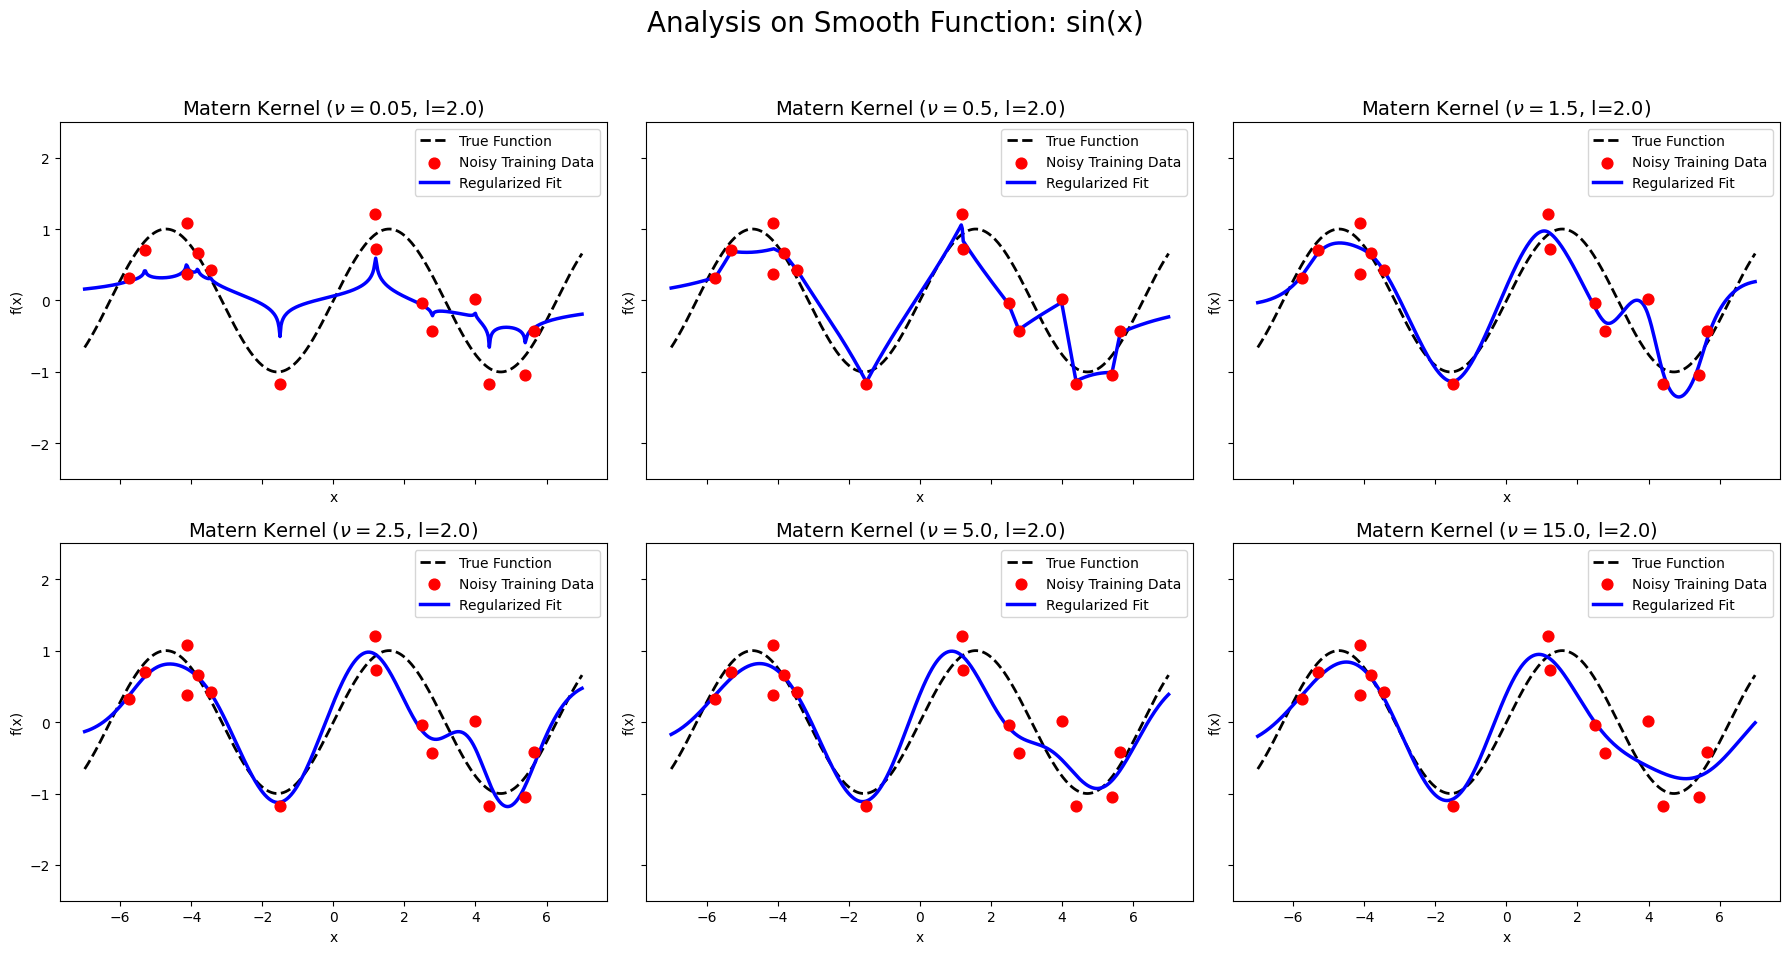


==== Analysis on Discontinuous Function: sign(x) ====


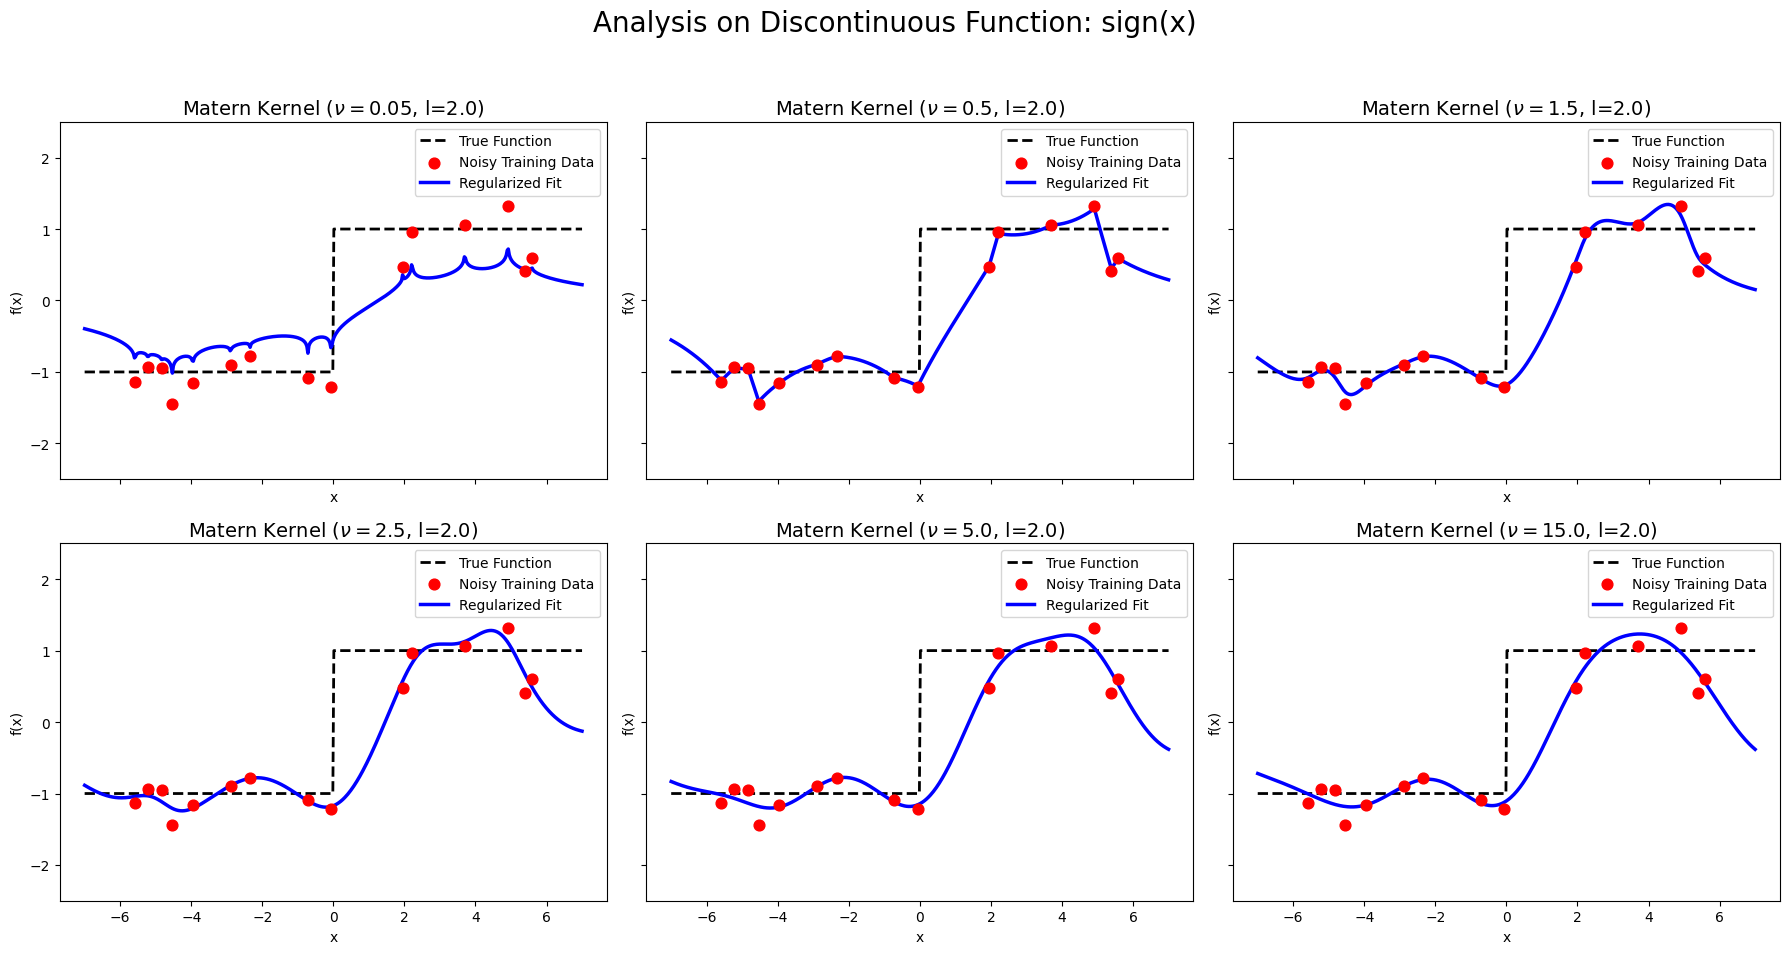

In [ ]:
length_scale = 2.0
regularization_lambda = 1e-3
nus = [0.05, 0.5, 1.5, 2.5, 5.0, 15.0]

def create_analysis_plots(X_train, y_train, true_func, fig_title):
    """Helper function to generate the 2x3 grid of plots for a given dataset."""
    X_plot = np.linspace(-7, 7, 500).reshape(-1, 1)
    y_true_plot = true_func(X_plot)

    fig, axes = plt.subplots(2, 3, figsize=(18, 10), sharex=True, sharey=True)
    axes = axes.ravel()

    for i, nu_val in enumerate(nus):
        ax = axes[i]

        # Solve Kernel Ridge Regression
        G = matern_kernel(X_train, X_train, l=length_scale, nu=nu_val)
        A = G + (regularization_lambda * N_POINTS) * np.eye(G.shape[0])
        alpha = np.linalg.solve(A, y_train)

        # Predict
        K_plot_train = matern_kernel(X_plot, X_train, l=length_scale, nu=nu_val)
        y_plot = K_plot_train @ alpha

        # Plotting
        ax.plot(X_plot, y_true_plot, 'k--', linewidth=2, label='True Function')
        ax.scatter(X_train, y_train, c='red', s=60, zorder=3, label='Noisy Training Data')
        ax.plot(X_plot, y_plot, 'b-', linewidth=2.5, label='Regularized Fit')

        title_str = f'Matern Kernel ($\\nu={nu_val}$, l={length_scale})'
        ax.set_title(title_str, fontsize=14)
        ax.set_xlabel('x')
        ax.set_ylabel('f(x)')
        ax.legend()
        ax.set_ylim(-2.5, 2.5)

    fig.suptitle(fig_title, fontsize=20)
    plt.tight_layout(rect=[0, 0.03, 1, 0.95])
    plt.show()

# Create plots for the first function
print("==== Analysis on Smooth Function: sin(x) ====")
create_analysis_plots(X_train1, y_train1, smooth_function, 'Analysis on Smooth Function: sin(x)')

# Create plots for the second function
print("\n==== Analysis on Discontinuous Function: sign(x) ====")
create_analysis_plots(X_train2, y_train2, discontinuous_function, 'Analysis on Discontinuous Function: sign(x)')